In [ ]:
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
dataf = pd.read_csv('/content/NetflixBestOf_reddit.csv')

In [ ]:
dataf.head()

,title,score,id,subreddit,url,num_comments,body,created,timestamp
0,"[Discussion] Am I just late to some change, or...",830,qtq00z,NetflixBestOf,https://www.reddit.com/r/NetflixBestOf/comment...,77,"A lot of these are older, but I'm seeing more ...",1.636897e+09,2021-11-14 14:38:17
1,[REQUEST] Shows similar to Only Murders in the...,36,qu96s0,NetflixBestOf,https://www.reddit.com/r/NetflixBestOf/comment...,7,Loved this one. Looking for similar shows that...,1.636955e+09,2021-11-15 06:37:27
2,[DISCUSSION] (US) The Fury of a Patient Man (T...,12,qu3xtc,NetflixBestOf,https://www.reddit.com/r/NetflixBestOf/comment...,2,"Reminiscent of A History of Violence, it is a ...",1.636937e+09,2021-11-15 01:46:35
3,[US] Love Harder (2021): this year's Netflix C...,514,qtc3c4,NetflixBestOf,https://www.netflix.com/us/title/81086631?s=a&...,86,NaN,1.636844e+09,2021-11-13 23:48:44
4,[DISCUSSION] Arcane (2021),110,qtipzk,NetflixBestOf,https://www.reddit.com/r/NetflixBestOf/comment...,40,Holy. Shit. This one came out of no where for ...,1.636867e+09,2021-11-14 06:14:27


In [ ]:
dataf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         462 non-null    object 
 1   score         462 non-null    int64  
 2   id            462 non-null    object 
 3   subreddit     462 non-null    object 
 4   url           462 non-null    object 
 5   num_comments  462 non-null    int64  
 6   body          354 non-null    object 
 7   created       462 non-null    float64
 8   timestamp     462 non-null    object 
dtypes: float64(1), int64(2), object(6)
memory usage: 32.6+ KB


In [ ]:
print("\nMissing Values:")
print(dataf.isnull().sum())



Missing Values:
title             0
score             0
id                0
subreddit         0
url               0
num_comments      0
body            108
created           0
timestamp         0
dtype: int64


In [ ]:
# Drop rows with missing 'body' or 'title' as they are essential for analysis
dataf.dropna(subset=['body', 'title'], inplace=True)

In [ ]:
# Reset index after dropping rows
dataf.reset_index(drop=True, inplace=True)

# Display the cleaned dataframe
print("\nCleaned Data:")
print(dataf.head())


Cleaned Data:
                                               title  score      id  \
0  [Discussion] Am I just late to some change, or...    830  qtq00z   
1  [REQUEST] Shows similar to Only Murders in the...     36  qu96s0   
2  [DISCUSSION] (US) The Fury of a Patient Man (T...     12  qu3xtc   
3                         [DISCUSSION] Arcane (2021)    110  qtipzk   
4  [ARG] The Haunting of Hill House (2018): A fam...    471  qt2977   

       subreddit                                                url  \
0  NetflixBestOf  https://www.reddit.com/r/NetflixBestOf/comment...   
1  NetflixBestOf  https://www.reddit.com/r/NetflixBestOf/comment...   
2  NetflixBestOf  https://www.reddit.com/r/NetflixBestOf/comment...   
3  NetflixBestOf  https://www.reddit.com/r/NetflixBestOf/comment...   
4  NetflixBestOf  https://www.reddit.com/r/NetflixBestOf/comment...   

   num_comments                                               body  \
0            77  A lot of these are older, but I'm seeing mor

In [ ]:
print("\nMissing Values:")
print(dataf.isnull().sum())



Missing Values:
title           0
score           0
id              0
subreddit       0
url             0
num_comments    0
body            0
created         0
timestamp       0
dtype: int64


In [ ]:
# Convert 'created' to datetime format
dataf['created'] = pd.to_datetime(dataf['created'])

# Convert 'timestamp' to datetime format (assuming it's already in datetime string format)
dataf['timestamp'] = pd.to_datetime(dataf['timestamp'])

# Extract relevant columns for sentiment analysis
data_sentiment = dataf[['title', 'body', 'score', 'created', 'subreddit']]

# Display the relevant columns
print("\nRelevant Columns for Sentiment Analysis:")
print(data_sentiment.head())

# Save the cleaned dataset for further analysis
data_sentiment.to_csv('cleaned_netflix_sentiment_data.csv', index=False)


Relevant Columns for Sentiment Analysis:
                                               title  \
0  [Discussion] Am I just late to some change, or...   
1  [REQUEST] Shows similar to Only Murders in the...   
2  [DISCUSSION] (US) The Fury of a Patient Man (T...   
3                         [DISCUSSION] Arcane (2021)   
4  [ARG] The Haunting of Hill House (2018): A fam...   

                                                body  score  \
0  A lot of these are older, but I'm seeing more ...    830   
1  Loved this one. Looking for similar shows that...     36   
2  Reminiscent of A History of Violence, it is a ...     12   
3  Holy. Shit. This one came out of no where for ...    110   
4   \n\nhttps://preview.redd.it/c5mdsenmgdz71.jpg...    471   

                        created      subreddit  
0 1970-01-01 00:00:01.636897097  NetflixBestOf  
1 1970-01-01 00:00:01.636954647  NetflixBestOf  
2 1970-01-01 00:00:01.636937195  NetflixBestOf  
3 1970-01-01 00:00:01.636866867  NetflixBestOf

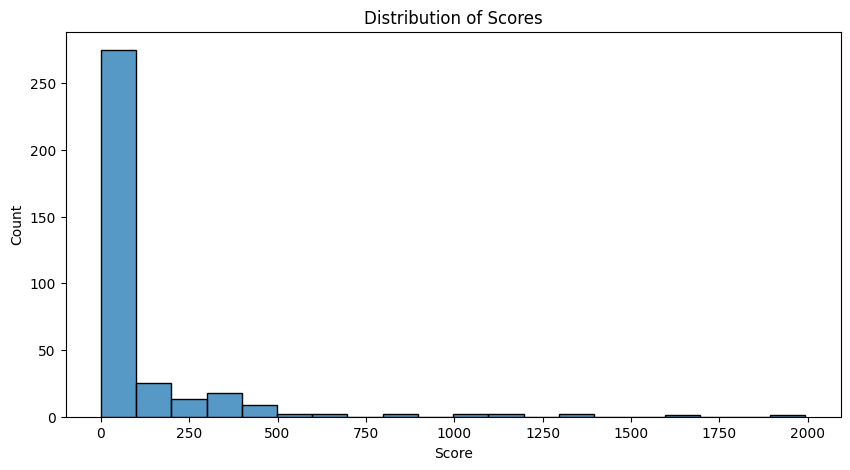

In [ ]:
# Visualize the distribution of scores
plt.figure(figsize=(10, 5))
sns.histplot(dataf['score'], bins=20)
plt.title('Distribution of Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

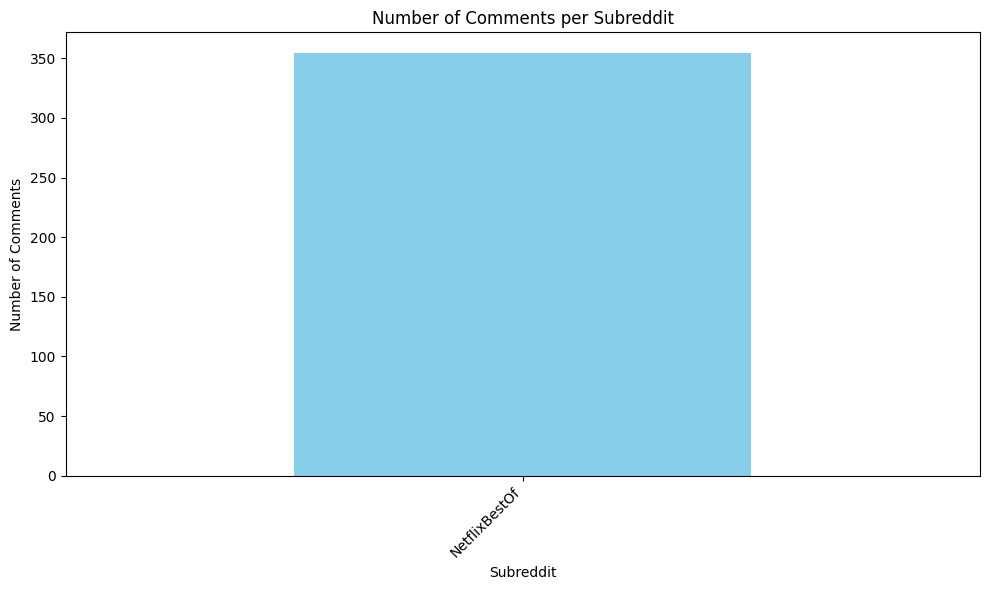

In [ ]:
# Visualize the number of comments per subreddit
plt.figure(figsize=(10, 6))
dataf['subreddit'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Number of Comments per Subreddit')
plt.xlabel('Subreddit')
plt.ylabel('Number of Comments')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

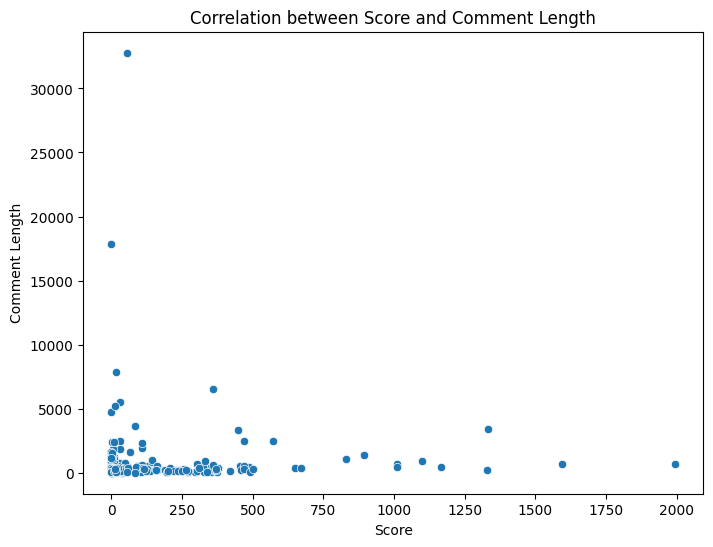

In [ ]:
# Visualize the correlation between score and comment length
plt.figure(figsize=(8, 6))
sns.scatterplot(x=dataf['score'], y=dataf['body'].str.len())
plt.title('Correlation between Score and Comment Length')
plt.xlabel('Score')
plt.ylabel('Comment Length')
plt.show()

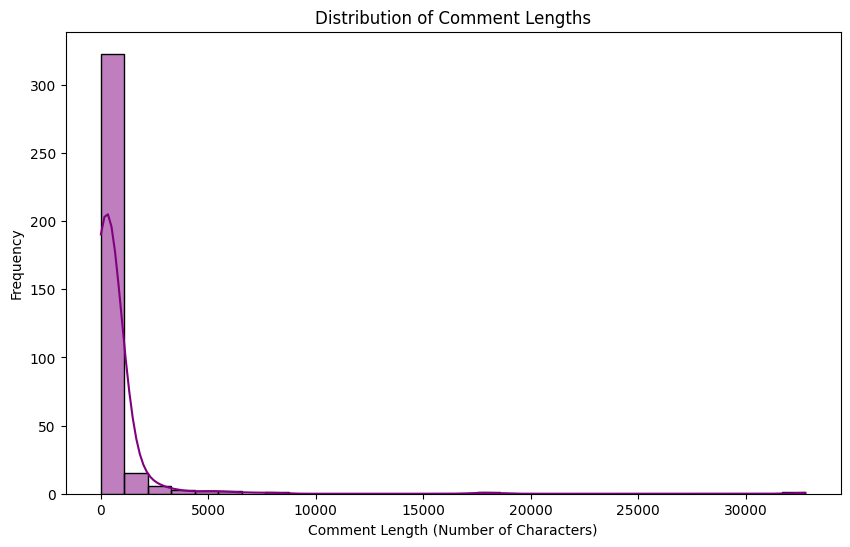

In [ ]:
# Visualization 1: Distribution of Comment Lengths
dataf['comment_length'] = dataf['body'].dropna().apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(dataf['comment_length'], bins=30, kde=True, color='purple')
plt.title('Distribution of Comment Lengths')
plt.xlabel('Comment Length (Number of Characters)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Function to perform sentiment analysis using TextBlob
def get_sentiment(text):
    analysis = TextBlob(text)
    # Classify the polarity
    if analysis.sentiment.polarity > 0:
        return 'positive'
    elif analysis.sentiment.polarity < 0:
        return 'negative'
    else:
        return 'neutral'

In [ ]:
# Apply the sentiment analysis function to the comments
dataf['sentiment'] = dataf['body'].apply(get_sentiment)

# Display the sentiment distribution
print("\nSentiment Distribution:")
print(dataf['sentiment'].value_counts())


Sentiment Distribution:
sentiment
positive    248
negative     87
neutral      19
Name: count, dtype: int64


<ipython-input-70-b0c63c1b7317>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataf, x='sentiment', palette='coolwarm')


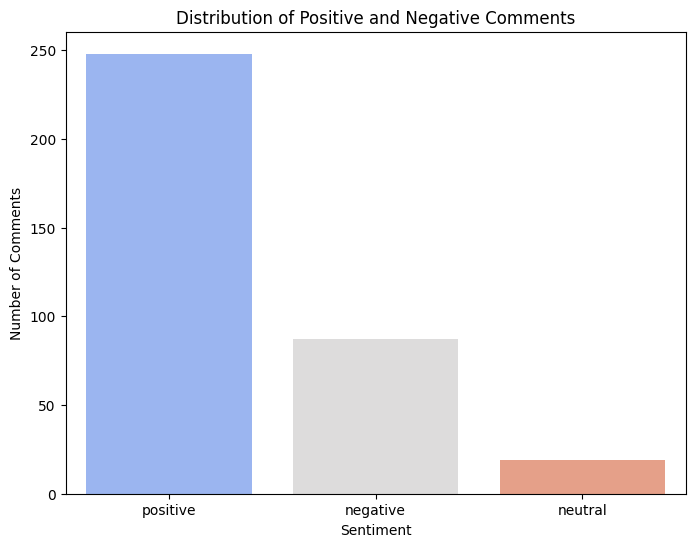

In [ ]:
# Visualize the distribution of sentiments
plt.figure(figsize=(8, 6))
sns.countplot(data=dataf, x='sentiment', palette='coolwarm')
plt.title('Distribution of Positive and Negative Comments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')
plt.show()

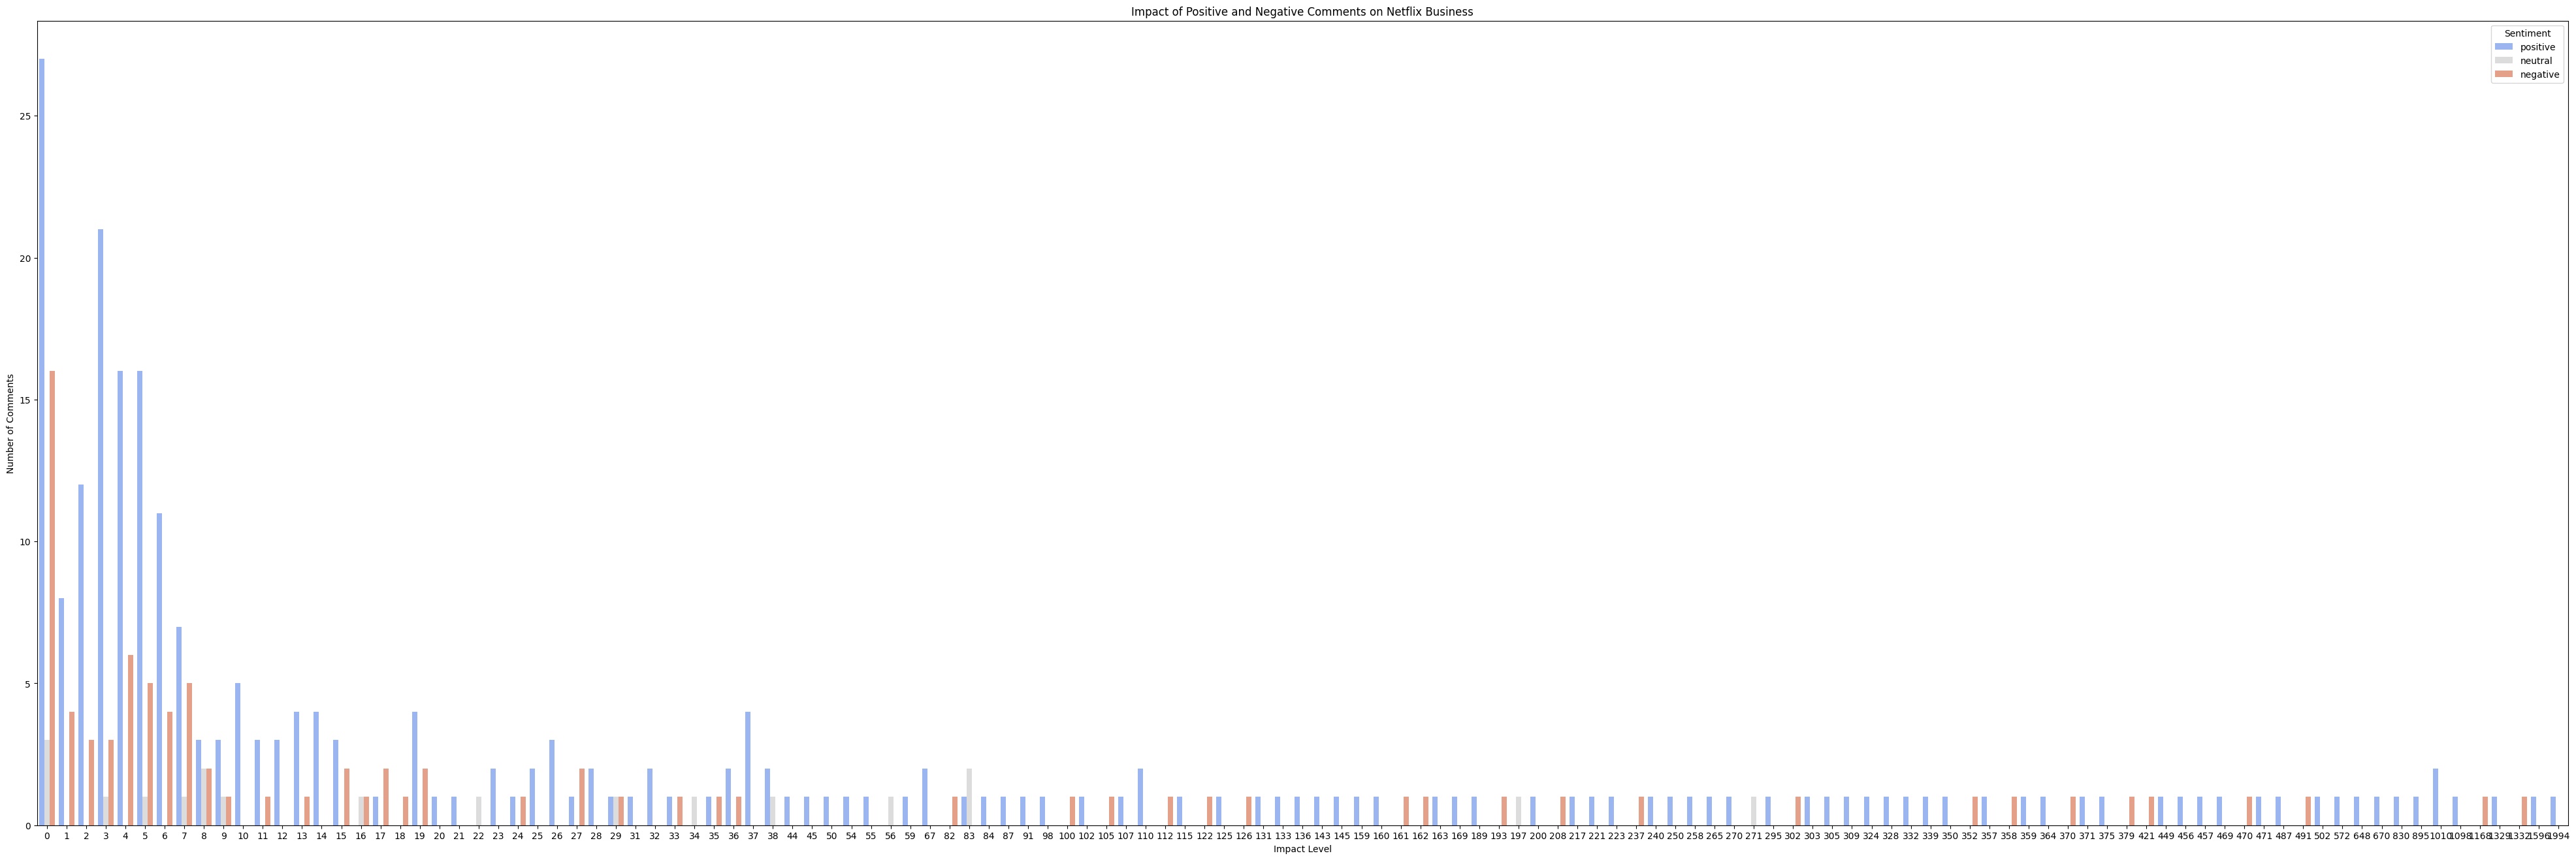

In [ ]:
# Visualize the impact of comments on business
plt.figure(figsize=(50, 16))
sns.countplot(data=dataf, x='score', hue='sentiment', palette='coolwarm')
plt.title('Impact of Positive and Negative Comments on Netflix Business')
plt.xlabel('Impact Level')
plt.ylabel('Number of Comments')
plt.legend(title='Sentiment')
plt.show()

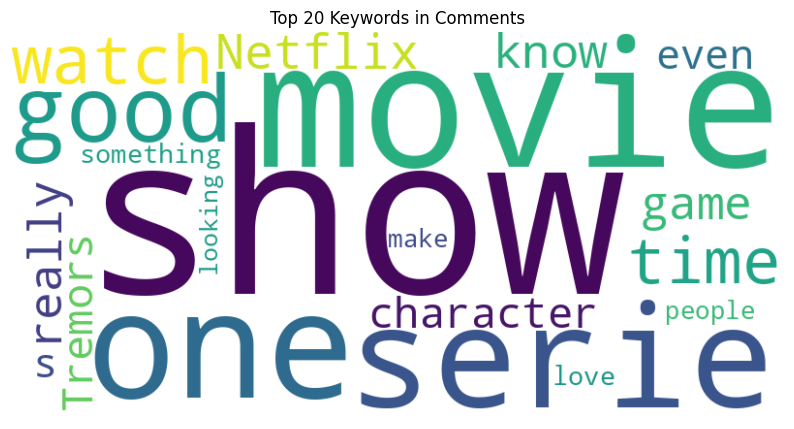

In [ ]:
# Visualization 4: Keyword Frequency (Top 20 Words)
text = ' '.join(dataf['body'].dropna())
wordcloud = WordCloud(width=800, height=400, max_words=20, background_color='white').generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 20 Keywords in Comments')
plt.show()

In [ ]:
# Import the necessary function
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix



In [ ]:
X = dataf['body']  # Define X as the feature matrix (text data)
y = dataf['sentiment']  # Define y as the target variable (sentiments)
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Function to perform sentiment analysis using TextBlob
def get_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity

In [ ]:
# Apply the sentiment analysis function to the comments
dataf['sentiment_score'] = dataf['body'].apply(get_sentiment)


In [ ]:
# Classify sentiments based on the sentiment score
def categorize_sentiment(score):
    if score > 0:
        return 'positive'
    elif score < 0:
        return 'negative'
    else:
        return 'neutral'

dataf['sentiment'] = dataf['sentiment_score'].apply(categorize_sentiment)

In [ ]:
# Prepare features and target variable
X = dataf['body']  # Features (comments)
y = dataf['sentiment']  # Target variable (sentiments)

In [ ]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Create a pipeline for Logistic Regression
logistic_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # Convert text data to TF-IDF features
    ('classifier', LogisticRegression(max_iter=1000))
])


In [ ]:
# Train the Logistic Regression model
logistic_pipeline.fit(X_train, y_train)

# Predict on the test set
y_pred_logistic = logistic_pipeline.predict(X_test)


In [ ]:
# Evaluate the Logistic Regression model
print("\nLogistic Regression Performance:")
print(classification_report(y_test, y_pred_logistic))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))



Logistic Regression Performance:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        22
    positive       0.69      1.00      0.82        49

    accuracy                           0.69        71
   macro avg       0.35      0.50      0.41        71
weighted avg       0.48      0.69      0.56        71

Confusion Matrix:
[[ 0 22]
 [ 0 49]]


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
  svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # Convert text data to TF-IDF features
    ('classifier', SVC(kernel='linear'))  # Linear kernel for SVM
])

In [ ]:
# Fit the SVM model to the training data
svm_pipeline.fit(X_train, y_train)  # Add this line to fit the pipeline

# Predict on the test set
y_pred_svm = svm_pipeline.predict(X_test)

In [ ]:
# Evaluate the SVM model
print("\nSupport Vector Machine Performance:")
print(classification_report(y_test, y_pred_svm))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))


Support Vector Machine Performance:
              precision    recall  f1-score   support

    negative       0.60      0.14      0.22        22
    positive       0.71      0.96      0.82        49

    accuracy                           0.70        71
   macro avg       0.66      0.55      0.52        71
weighted avg       0.68      0.70      0.63        71

Confusion Matrix:
[[ 3 19]
 [ 2 47]]
